# Solution - LightGBM on Census Income (Adult)

Instructor solution for `adult_lightgbm.ipynb`. **LightGBM as one lens** (single tree /
random forest / gradient boosting from the same library), plus a **logistic-regression
baseline** for contrast, tuning, and a read + audit (importance, monotonic constraint,
subgroup slice-check by `sex`).

Run top to bottom with the `ma` kernel. `random_state = 509`. ~76% earn `<=50K`, so we report
**ROC-AUC and F1**, not accuracy.

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from lightgbm import LGBMClassifier, early_stopping

SEED = 509
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
print('raw shape:', df.shape)
df.head(3)

raw shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


## Part 0 - Clean and explore

- **Target:** `y = (class == '>50K')`.
- **Drop** `fnlwgt` (a census *sampling weight*, not a predictor) and `education` (a string
  duplicate of the ordinal `education-num` - we keep the numeric one so we can put a monotonic
  constraint on it later).
- **Missing values** (`workclass`, `occupation`, `native-country`) stay as `NaN`: LightGBM
  handles them natively, no imputation needed.
- **Categoricals** keep the pandas `category` dtype - LightGBM reads them directly.
- One **stratified** split, reused everywhere.

In [2]:
y = (df['class'] == '>50K').astype(int)
X = df.drop(columns=['class', 'fnlwgt', 'education'])
cat_cols = X.select_dtypes('category').columns.tolist()
num_cols = X.select_dtypes('number').columns.tolist()

print(f"n = {len(X)},  features = {X.shape[1]}  ({len(cat_cols)} categorical, {len(num_cols)} numeric)")
print('positive (>50K) rate:', round(float(y.mean()), 3),
      '| always-<=50K accuracy:', round(float(1 - y.mean()), 3))
print('\nmissing values:')
print(X.isna().sum()[X.isna().sum() > 0].to_string())
print('\nnative-country levels:', X['native-country'].nunique())

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
print('\ntrain', X_tr.shape, 'test', X_te.shape)

n = 48842,  features = 12  (7 categorical, 5 numeric)
positive (>50K) rate: 0.239 | always-<=50K accuracy: 0.761

missing values:
workclass         2799
occupation        2809
native-country     857

native-country levels: 41

train (36631, 12) test (12211, 12)


**A quick look:** the positive rate climbs steadily with `education-num` - a near-monotone
signal we will lean on with a monotonic constraint in Part 3.

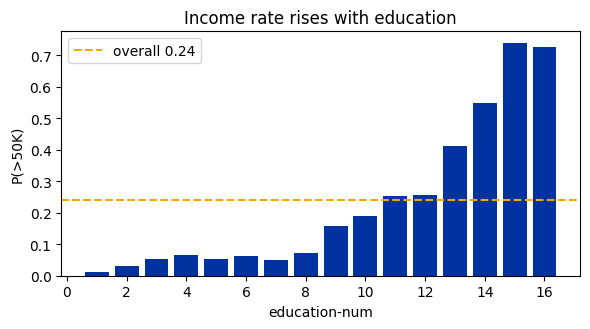

In [3]:
rate = pd.DataFrame({'ed': X['education-num'], 'y': y}).groupby('ed')['y'].mean()
plt.figure(figsize=(6, 3.4))
plt.bar(rate.index, rate.values, color='#0033A0')
plt.axhline(y.mean(), color='#F2A800', ls='--', label=f'overall {y.mean():.2f}')
plt.xlabel('education-num'); plt.ylabel('P(>50K)'); plt.legend()
plt.title('Income rate rises with education'); plt.tight_layout(); plt.show()

## Part 1 - Baselines: one library (+ a linear reference)

A running **scoreboard**. First the *non-tree* reference - **logistic regression** - which,
unlike the trees, cannot eat the raw frame: it needs **imputation + one-hot + scaling**. Then
the three tree ensembles, all from LightGBM on the *same raw frame*.

In [4]:
scores = {}
def record(name, model):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    scores[name] = dict(auc=roc_auc_score(y_te, proba), f1=f1_score(y_te, pred),
                        acc=accuracy_score(y_te, pred))
    print(f"{name:24s} AUC={scores[name]['auc']:.3f}  F1={scores[name]['f1']:.3f}  "
          f"acc={scores[name]['acc']:.3f}")
    return model

# --- logistic-regression baseline: needs real preprocessing ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)])
logreg = record('logistic regression', Pipeline([('pre', pre),
                                                 ('clf', LogisticRegression(max_iter=1000))]))

logistic regression      AUC=0.905  F1=0.661  acc=0.853


In [5]:
# --- three ensembles, one library, on the RAW frame (NaN + categoricals handled natively) ---
record('single tree (LGBM)', LGBMClassifier(
    n_estimators=1, learning_rate=1.0, random_state=SEED, verbose=-1, n_jobs=1))
record('random forest (LGBM)', LGBMClassifier(
    boosting_type='rf', bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
    n_estimators=300, random_state=SEED, verbose=-1, n_jobs=1))
record('gradient boosting (LGBM)', LGBMClassifier(
    random_state=SEED, verbose=-1, n_jobs=1))
print('\nOrdering: logreg ~ single tree < random forest < gradient boosting.')
print('A well-preprocessed linear model only matches ONE tree; boosting on the raw frame wins.')

single tree (LGBM)       AUC=0.902  F1=0.664  acc=0.858


random forest (LGBM)     AUC=0.914  F1=0.685  acc=0.864


gradient boosting (LGBM) AUC=0.929  F1=0.712  acc=0.874

Ordering: logreg ~ single tree < random forest < gradient boosting.
A well-preprocessed linear model only matches ONE tree; boosting on the raw frame wins.


**Native categoricals vs one-hot.** LightGBM can split on categories directly. One-hot encoding
`native-country` (41 levels) alone explodes the column count - for little or no gain, and slower.

In [6]:
def timed_fit_auc(Xtr, Xte, tag):
    t0 = time.perf_counter()
    m = LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1).fit(Xtr, y_tr)
    dt = time.perf_counter() - t0
    auc = roc_auc_score(y_te, m.predict_proba(Xte)[:, 1])
    print(f"{tag:16s} cols={Xtr.shape[1]:4d}  AUC={auc:.3f}  fit={dt:.2f}s")

timed_fit_auc(X_tr, X_te, 'native cats')
Xtr_oh = pd.get_dummies(X_tr, columns=cat_cols)
Xte_oh = pd.get_dummies(X_te, columns=cat_cols).reindex(columns=Xtr_oh.columns, fill_value=0)
timed_fit_auc(Xtr_oh, Xte_oh, 'one-hot')

native cats      cols=  12  AUC=0.929  fit=0.60s


one-hot          cols=  88  AUC=0.929  fit=0.68s


## Part 2 - Make the GBDT win (tuning)

Carve a **validation** slice out of train for early stopping and model selection; the **test**
set is touched only for the final number. Tune in the [20] order: `learning_rate` (with early
stopping picking the tree count) -> `num_leaves` / `min_data_in_leaf` -> regularization.

In [7]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr)

def fit_es(**params):
    m = LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=1, **params)
    m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric='auc',
          callbacks=[early_stopping(50, verbose=False)])
    return m

def val_auc(m):
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

# 1) learning rate (trees chosen by early stopping)
for lr in [0.02, 0.05, 0.1]:
    m = fit_es(learning_rate=lr)
    print(f"lr={lr:<5} best_iter={m.best_iteration_:4d}  val AUC={val_auc(m):.4f}")

lr=0.02  best_iter= 611  val AUC=0.9265


lr=0.05  best_iter= 236  val AUC=0.9265


lr=0.1   best_iter= 115  val AUC=0.9268


In [8]:
# 2) num_leaves / min_data_in_leaf, around the best learning rate
best = (None, 0.0, None)
for nl in [31, 63, 127]:
    for mdl_ in [20, 50, 100]:
        m = fit_es(learning_rate=0.05, num_leaves=nl, min_child_samples=mdl_)
        a = val_auc(m)
        if a > best[1]:
            best = ({'num_leaves': nl, 'min_child_samples': mdl_}, a, m)
print('best leaves/min_data:', best[0], 'val AUC', round(best[1], 4))

# 3) L1/L2 regularization on top
best_params = dict(learning_rate=0.05, **best[0])
for l1, l2 in [(0.0, 0.0), (1.0, 1.0), (5.0, 5.0)]:
    m = fit_es(reg_alpha=l1, reg_lambda=l2, **best_params)
    a = val_auc(m)
    print(f"reg_alpha={l1} reg_lambda={l2}  val AUC={a:.4f}")
    if a >= best[1]:
        best = ({**best[0], 'reg_alpha': l1, 'reg_lambda': l2}, a, m)
best_params = dict(learning_rate=0.05, **best[0])
print('\nchosen params:', best_params)

best leaves/min_data: {'num_leaves': 31, 'min_child_samples': 20} val AUC 0.9265


reg_alpha=0.0 reg_lambda=0.0  val AUC=0.9265


reg_alpha=1.0 reg_lambda=1.0  val AUC=0.9257


reg_alpha=5.0 reg_lambda=5.0  val AUC=0.9242

chosen params: {'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.0}


In [9]:
# refit the tuned model on ALL of train (early stopping on val for the tree count), then record
tuned = fit_es(**best_params)
best_gbdt = LGBMClassifier(n_estimators=tuned.best_iteration_, random_state=SEED,
                           verbose=-1, n_jobs=1, **best_params)
record('tuned GBDT', best_gbdt)

tuned GBDT               AUC=0.930  F1=0.709  acc=0.873


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,236
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


**Imbalance + threshold.** `scale_pos_weight` re-weights the minority (helps F1, leaves the
ranking/AUC ~unchanged). Then pick the **decision threshold by F1** on validation, not the
default 0.5.

In [10]:
spw = float((y_fit == 0).sum() / (y_fit == 1).sum())
bal = fit_es(scale_pos_weight=spw, **best_params)
auc_bal = roc_auc_score(y_te, bal.predict_proba(X_te)[:, 1])
f1_bal = f1_score(y_te, (bal.predict_proba(X_te)[:, 1] >= 0.5).astype(int))
print(f"scale_pos_weight={spw:.2f}: test AUC={auc_bal:.3f}  F1@0.5={f1_bal:.3f}  "
      f"(vs tuned AUC={scores['tuned GBDT']['auc']:.3f} F1={scores['tuned GBDT']['f1']:.3f})")

# threshold by F1 on the validation set, applied to test
pv = best_gbdt.predict_proba(X_val)[:, 1]
ths = np.linspace(0.1, 0.9, 81)
best_th = ths[int(np.argmax([f1_score(y_val, (pv >= t).astype(int)) for t in ths]))]
pt = best_gbdt.predict_proba(X_te)[:, 1]
print(f"best F1 threshold = {best_th:.2f}:  test F1 {f1_score(y_te,(pt>=0.5).astype(int)):.3f} "
      f"(@0.5) -> {f1_score(y_te,(pt>=best_th).astype(int)):.3f} (@{best_th:.2f})")

scale_pos_weight=3.18: test AUC=0.929  F1@0.5=0.717  (vs tuned AUC=0.930 F1=0.709)


best F1 threshold = 0.44:  test F1 0.709 (@0.5) -> 0.720 (@0.44)


## Part 3 - Read it and audit it

**Gain vs permutation importance.** Gain (from train) leans on high-cardinality splits;
permutation (on test) says what actually moves the held-out score.

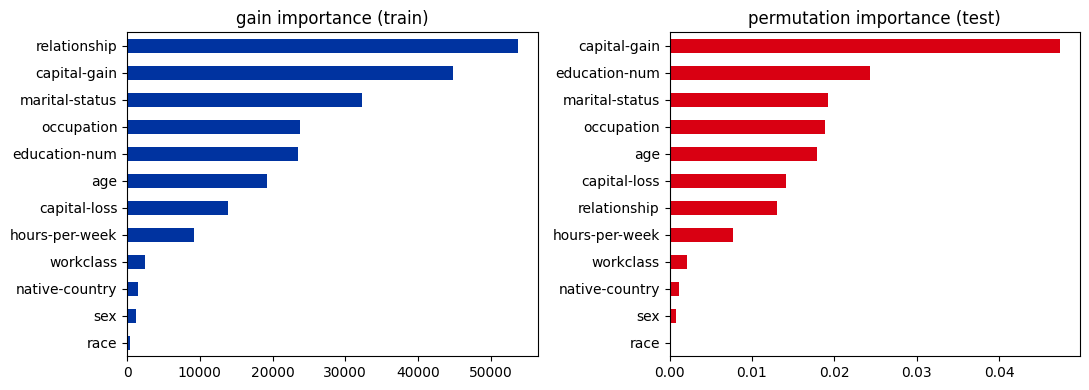

gain top-3     : ['relationship', 'capital-gain', 'marital-status']
permutation top-3: ['capital-gain', 'education-num', 'marital-status']


In [11]:
from sklearn.inspection import permutation_importance
gain = pd.Series(best_gbdt.booster_.feature_importance(importance_type='gain'),
                 index=X_tr.columns).sort_values(ascending=False)
perm = permutation_importance(best_gbdt, X_te, y_te, n_repeats=5,
                              random_state=SEED, n_jobs=1)
perm = pd.Series(perm.importances_mean, index=X_tr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
gain.iloc[::-1].plot.barh(ax=ax[0], color='#0033A0'); ax[0].set_title('gain importance (train)')
perm.iloc[::-1].plot.barh(ax=ax[1], color='#D90012'); ax[1].set_title('permutation importance (test)')
plt.tight_layout(); plt.show()
print('gain top-3     :', list(gain.index[:3]))
print('permutation top-3:', list(perm.index[:3]))

### Linear vs non-linear: which features have a non-linear effect?

Logistic regression can only use a **numeric** feature through a **linear, monotone** effect. If
gradient boosting extracts far more from a numeric feature than logreg does, the extra signal is
exactly what a line cannot represent - **curvature or a non-monotone shape**. So we compare
**permutation importance** (drop in test ROC-AUC) for both models: a large **gbdt - logreg gap**
on a numeric feature flags non-linearity.

*Reading a numeric gap:* it can come from **curvature / non-monotonicity** *or* from
**interactions** with other features - additive logreg captures neither. The
**partial-dependence plot disambiguates**: a clearly curved or non-monotone univariate PDP
(like `age`) is curvature; a flat PDP despite a large gap would instead point to interactions.

*Caveat:* for **categorical** features the one-hot logreg already fits an arbitrary per-level
effect, so it is not linearity-limited there - a categorical gap means **interactions or
redundancy**, not univariate curvature. Read the *numeric* rows for the non-linearity story.

In [12]:
imp_lr = permutation_importance(logreg, X_te, y_te, scoring='roc_auc',
                                n_repeats=5, random_state=SEED, n_jobs=1).importances_mean
imp_gb = permutation_importance(best_gbdt, X_te, y_te, scoring='roc_auc',
                                n_repeats=5, random_state=SEED, n_jobs=1).importances_mean
gap = pd.DataFrame({'logreg': imp_lr, 'gbdt': imp_gb}, index=X_tr.columns)
gap['gap'] = gap['gbdt'] - gap['logreg']
gap['kind'] = ['numeric' if c in num_cols else 'categorical' for c in X_tr.columns]
print(gap.sort_values('gap', ascending=False).round(4).to_string())
print("\nBiggest positive gaps are NUMERIC (age, capital-gain): boosting sees a shape logreg"
      " cannot. education-num has ~zero/negative gap, so its effect is essentially linear.")

                logreg    gbdt     gap         kind
age             0.0061  0.0496  0.0436      numeric
capital-gain    0.0328  0.0573  0.0245      numeric
capital-loss    0.0057  0.0169  0.0112      numeric
hours-per-week  0.0090  0.0129  0.0039      numeric
relationship    0.0099  0.0137  0.0037  categorical
race            0.0004  0.0004  0.0000  categorical
workclass       0.0025  0.0023 -0.0002  categorical
native-country  0.0016  0.0013 -0.0003  categorical
occupation      0.0192  0.0168 -0.0023  categorical
sex             0.0071  0.0010 -0.0062  categorical
education-num   0.0358  0.0251 -0.0107      numeric
marital-status  0.1444  0.0364 -0.1080  categorical

Biggest positive gaps are NUMERIC (age, capital-gain): boosting sees a shape logreg cannot. education-num has ~zero/negative gap, so its effect is essentially linear.


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


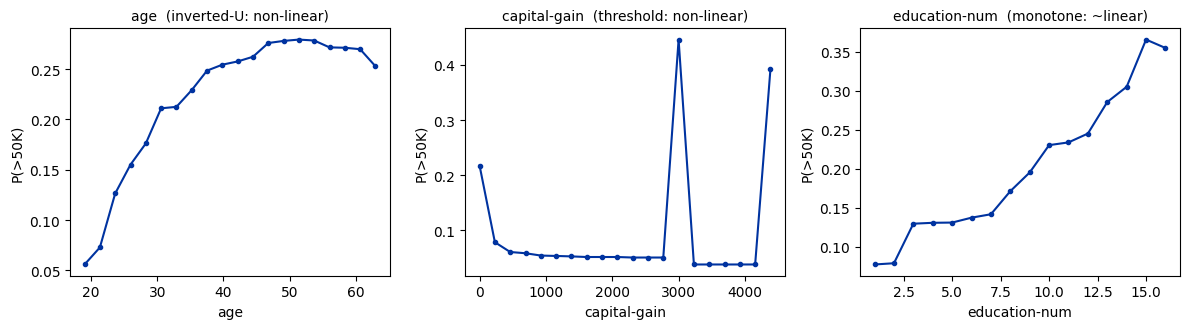

PDPs confirm the gap: age peaks then declines, capital-gain jumps at a threshold (both non-linear); education-num rises monotonically (linear, so logreg already gets it).


In [13]:
from sklearn.inspection import partial_dependence
titles = {'age': 'age  (inverted-U: non-linear)',
          'capital-gain': 'capital-gain  (threshold: non-linear)',
          'education-num': 'education-num  (monotone: ~linear)'}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, f in zip(axes, titles):
    j = list(X_tr.columns).index(f)
    p = partial_dependence(best_gbdt, X_te, [j], grid_resolution=20, kind='average')
    ax.plot(p['grid_values'][0], p['average'][0], '-o', ms=3, color='#0033A0')
    ax.set_xlabel(f); ax.set_ylabel('P(>50K)'); ax.set_title(titles[f], fontsize=10)
plt.tight_layout(); plt.show()
print("PDPs confirm the gap: age peaks then declines, capital-gain jumps at a threshold "
      "(both non-linear); education-num rises monotonically (linear, so logreg already gets it).")

**Monotonic constraint on `education-num`.** We saw income rise with education; force the model
to respect that (non-decreasing). It costs at most a hair of AUC and makes the response sensible.

In [14]:
constr = [1 if c == 'education-num' else 0 for c in X_tr.columns]
mono = LGBMClassifier(n_estimators=best_gbdt.n_estimators, monotone_constraints=constr,
                      random_state=SEED, verbose=-1, n_jobs=1, **best_params).fit(X_tr, y_tr)
print(f"AUC  unconstrained={scores['tuned GBDT']['auc']:.3f}  "
      f"monotone(education-num)={roc_auc_score(y_te, mono.predict_proba(X_te)[:,1]):.3f}")

AUC  unconstrained=0.930  monotone(education-num)=0.930


**Subgroup slice-check by `sex`.** A strong overall AUC can hide very different per-group
behavior. We split the test set by `sex` and report per-group ROC-AUC and predicted-positive rate.

In [15]:
proba_te = best_gbdt.predict_proba(X_te)[:, 1]
print(f"overall: AUC={roc_auc_score(y_te, proba_te):.3f}  "
      f"pred>50K={ (proba_te>=best_th).mean():.3f}  true>50K={y_te.mean():.3f}")
sex_te = X_te['sex'].astype(str).values
for g in ['Male', 'Female']:
    mask = sex_te == g
    print(f"{g:7s} n={mask.sum():5d}  AUC={roc_auc_score(y_te[mask], proba_te[mask]):.3f}  "
          f"pred>50K={(proba_te[mask]>=best_th).mean():.3f}  "
          f"true>50K={y_te.values[mask].mean():.3f}")

overall: AUC=0.930  pred>50K=0.223  true>50K=0.239
Male    n= 8091  AUC=0.912  pred>50K=0.289  true>50K=0.306
Female  n= 4120  AUC=0.947  pred>50K=0.092  true>50K=0.108


**Reflection.**

- **Did tree < RF < GBDT hold?** Yes. A single tree (~0.90 AUC) is roughly matched by the
  well-preprocessed **logistic regression** baseline; the **random forest** improves on it, and
  **gradient boosting** wins clearly (~0.93). Tuning adds a further small bump.
- **Where did tuning help most?** `learning_rate` + early stopping (the tree count), then
  `num_leaves` / `min_child_samples` to control complexity. Regularization gave little here.
- **Categoricals:** native handling matched one-hot on AUC with **far fewer columns** and faster
  fits - one-hot's only effect was to blow up the width via `native-country`.
- **Imbalance & threshold:** `scale_pos_weight` left AUC alone (it is threshold-independent) but,
  with an F1-chosen threshold, improved F1 - the operating point, not the ranking, was the lever.
- **Audit:** gain and permutation importance broadly agree on the top drivers
  (`marital-status`/`relationship`, `capital-gain`, `education-num`, `age`). The **slice-check**
  shows the model predicts `>50K` far more often for men than women - a real gap to be aware of
  before deploying such a model.
- **Linear vs non-linear:** comparing logreg and GBDT permutation importance, the biggest gaps
  are on `age` and `capital-gain` - their partial-dependence curves are an inverted-U and a
  threshold, non-linear shapes a linear model cannot fit, which is a good chunk of why boosting
  beats the logreg baseline. `education-num` is essentially linear (no gap), and the categorical
  gaps reflect encoding/interactions, not curvature.
- **Next:** try XGBoost / CatBoost, calibrate the probabilities ([14]), and add a stacking layer.

## Scoreboard

In [16]:
board = pd.DataFrame(scores).T[['auc', 'f1', 'acc']].round(3)
print(board.to_string())
board

                            auc     f1    acc
logistic regression       0.905  0.661  0.853
single tree (LGBM)        0.902  0.664  0.858
random forest (LGBM)      0.914  0.685  0.864
gradient boosting (LGBM)  0.929  0.712  0.874
tuned GBDT                0.930  0.709  0.873


,auc,f1,acc
logistic regression,0.905,0.661,0.853
single tree (LGBM),0.902,0.664,0.858
random forest (LGBM),0.914,0.685,0.864
gradient boosting (LGBM),0.929,0.712,0.874
tuned GBDT,0.930,0.709,0.873
